In [1]:
from lib.viz.plotting import plot_sagd_heatmap_row_with_prob, plot_sagd_heatmap_row_mnist, plot_tsne, plot_ctd_stratified
from lib.ou_model import find_third_phase_onset
from lib.diffusion_model.resnet_classifier import ResNet

import numpy as np
import joblib
from pathlib import Path

import matplotlib.gridspec as gridspec
from matplotlib.animation import FuncAnimation
from matplotlib import pyplot as plt
import seaborn as sns

from sklearn.decomposition import PCA
from torch import nn
import torch
import torchvision

import warnings
from scipy.integrate import IntegrationWarning
warnings.filterwarnings("ignore", category=IntegrationWarning)

In [2]:
def get_node_labels(samples, model, device, batch_size=64):
    """
    samples: (N, C, H, W) tensor
    returns: (N,) numpy array of predicted labels
    """
    if isinstance(samples, np.ndarray):
        samples = torch.tensor(samples).float()
    
    all_labels = []
    model.eval()
    with torch.no_grad():
        for i in range(0, len(samples), batch_size):
            batch  = samples[i:i+batch_size].to(device)
            batch  = tf(batch)
            logits = model(batch)
            preds  = torch.argmax(logits, dim=1).cpu().numpy()
            all_labels.append(preds)
    
    return np.concatenate(all_labels)

In [3]:
ROOT = Path('/extra/shared/groups/marinaivan/data_marina')

## MNIST Classifier

In [4]:
classifier_path = ROOT / Path('training/mnist/classifier/mnist_classifier_3c.pth')

In [5]:
# load mnist classifier
DATASET = 'MNIST'
DEVICE='cuda:0'
model = ResNet(num_classes=3).to(DEVICE)
model.load_state_dict(
    torch.load( classifier_path, weights_only=True)
)
model.eval()
tf = torchvision.transforms.Resize(224)

## MNIST - 2 classes: 1, 8

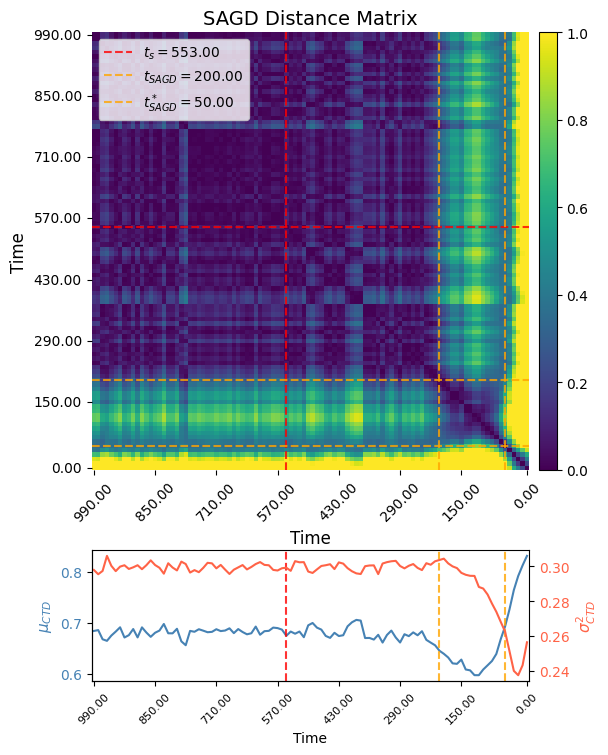

In [7]:
plot_sagd_heatmap_row_mnist(
    exp_path= ROOT / Path("training/diffusion_models/Saves/History/MNIST_5000_newUnet/"), 
    steps=[100000]
)

In [6]:
exp_path = ROOT / Path("training/diffusion_models/Saves/History/MNIST_5000_newUnet/")
subdirs = [exp_path / Path(exp_path.name + "_" + str(step)) for step in [100000]]
W_list = []
time_snaps_vector_list = []
sagd_dms = []
ts_list, tsagd_list, t_star_list = [], [], []
std = 1.0
mu = None
ctds_list = []
params = joblib.load(exp_path / "config.jbl")

for subdir in subdirs:
    history = joblib.load(subdir / "history.jbl")
    snaps = np.asarray(list(history.keys()))
    time_snaps_vector_list.append(snaps)
    breakpoints = joblib.load(subdir / "clusters.jbl")
    W_list.append(joblib.load(subdir / "Ws.jbl"))
    ctds = joblib.load(subdir / "CTDs.jbl")
    ctds_list.append(ctds)
    sagd_dms.append(joblib.load(subdir / "SAGD.jbl"))
    ts_list.append(params['ts_step'])
    tsagd_list.append(snaps[breakpoints[0]])
    t_star_list.append(find_third_phase_onset(ctds['CTDs'], snaps))

In [8]:
# get labels from samples at t=0
X_final = history[snaps[-1]]  # (N, C, H, W)
node_labels = get_node_labels(X_final, model, DEVICE)
print(f"Label distribution: {np.bincount(node_labels)}")

Label distribution: [   0 1049  951]


In [9]:
tss = [ts_list[0]-3, tsagd_list[0], t_star_list[0]]
t_titles = ['t_s', 't_sagd', 't*_sagd']
indcs = [idx for j in tss for idx, i in enumerate(snaps)  if i==j ]

Running t-SNE...
Running t-SNE...
Running t-SNE...


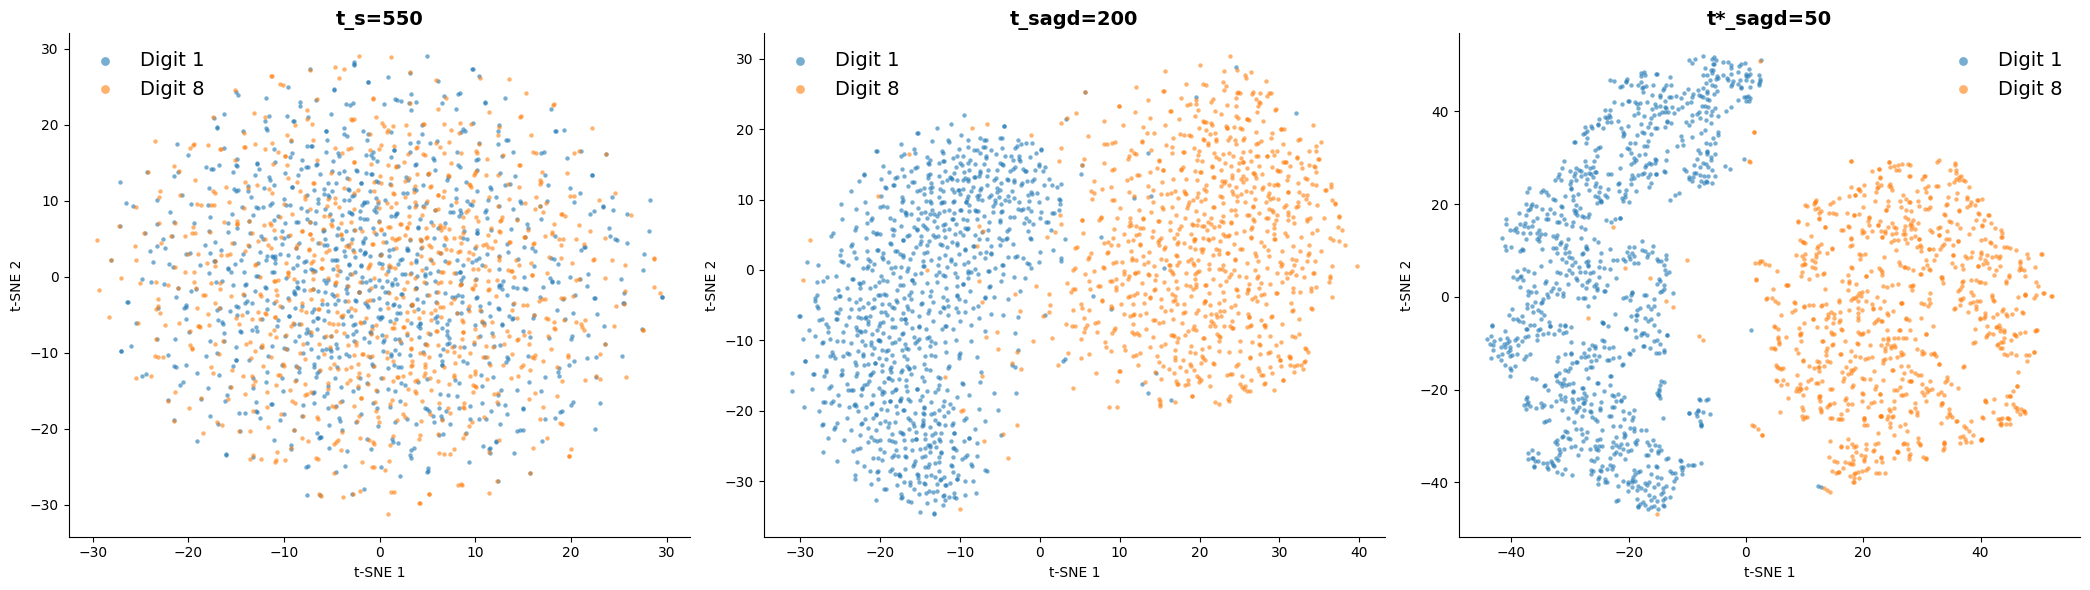

In [10]:
n = len(indcs)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
if n == 1:
    axes = [axes]

for count, (ax, idx) in enumerate(zip(axes, indcs)):
    X_final = history[snaps[idx]]  # (N, C, H, W)
    X_flat = X_final.reshape(2000, -1)  # (2000, 1024)
    X_pca = PCA(n_components=50).fit_transform(X_flat)
    plot_tsne(X_pca, node_labels, title=f"{t_titles[count]}={tss[count]}", ax=ax, save=False, class_names={1: 'Digit 1', 2: 'Digit 8'})
plt.tight_layout()
plt.savefig("figs/tsne_row.jpg", dpi=150, bbox_inches='tight')
plt.show()

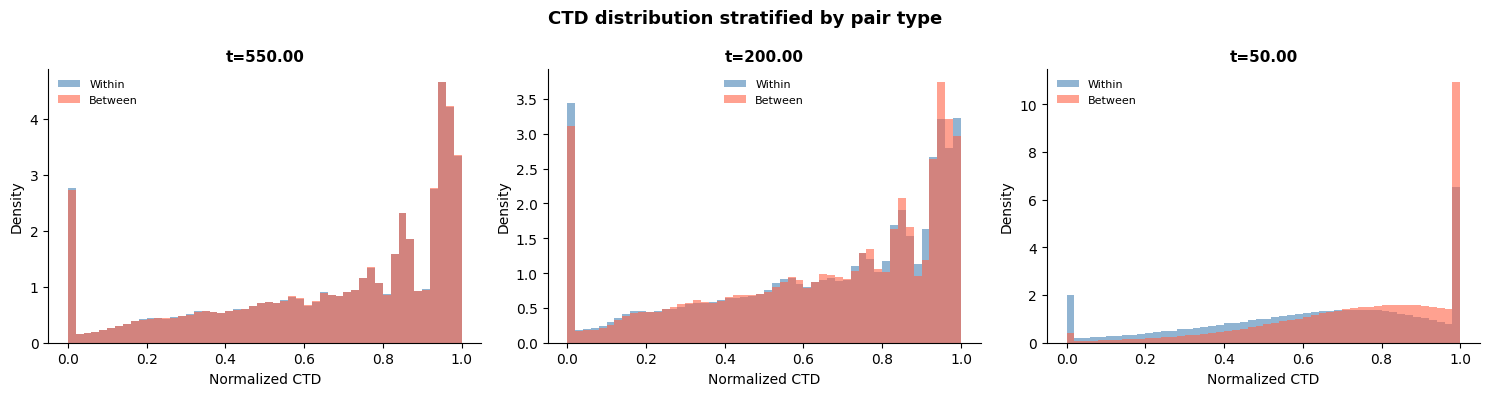

In [11]:
plot_ctd_stratified(ctds, sagd_dms[0], node_labels, snaps, t_values_to_plot=[snaps[idx] for idx in indcs])

## MNIST - 3 classes: 0, 1, 8

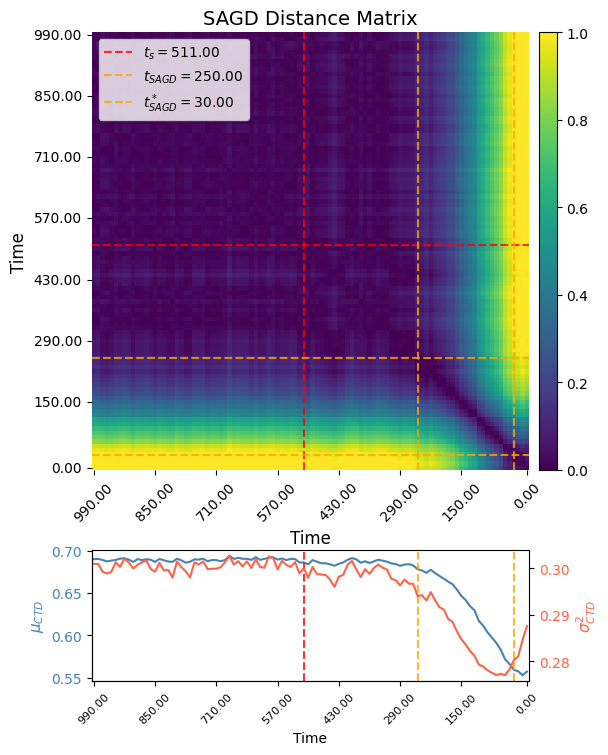

In [11]:
plot_sagd_heatmap_row_mnist(
    exp_path= ROOT / Path("training/diffusion_models/Saves/History/MNIST_15000_3class_newUnet/"), 
    steps=[150000]
)

In [12]:
exp_path = ROOT / Path("training/diffusion_models/Saves/History/MNIST_15000_3class_newUnet/")
subdirs = [exp_path / Path(exp_path.name + "_" + str(step)) for step in [150000]]
W_list = []
time_snaps_vector_list = []
sagd_dms = []
ts_list, tsagd_list, t_star_list = [], [], []
std = 1.0
mu = None
ctds_list = []
params = joblib.load(exp_path / "config.jbl")

for subdir in subdirs:
    history = joblib.load(subdir / "history.jbl")
    snaps = np.asarray(list(history.keys()))
    time_snaps_vector_list.append(snaps)
    breakpoints = joblib.load(subdir / "clusters.jbl")
    W_list.append(joblib.load(subdir / "Ws.jbl"))
    ctds = joblib.load(subdir / "CTDs.jbl")
    ctds_list.append(ctds)
    sagd_dms.append(joblib.load(subdir / "SAGD.jbl"))
    ts_list.append(params['ts_step'])
    tsagd_list.append(snaps[breakpoints[0]])
    t_star_list.append(find_third_phase_onset(ctds['CTDs'], snaps))

In [13]:
# get labels from samples at t=0
X_final = history[snaps[-1]]  # (N, C, H, W)
node_labels = get_node_labels(X_final, model, DEVICE)
print(f"Label distribution: {np.bincount(node_labels)}")

Label distribution: [565 790 645]


In [18]:
tss = [ts_list[0]-1, tsagd_list[0], t_star_list[0]]
t_titles = ['t_s', 't_sagd', 't*_sagd']
indcs = [idx for j in tss for idx, i in enumerate(snaps)  if i==j ]

Running t-SNE...
Running t-SNE...
Running t-SNE...


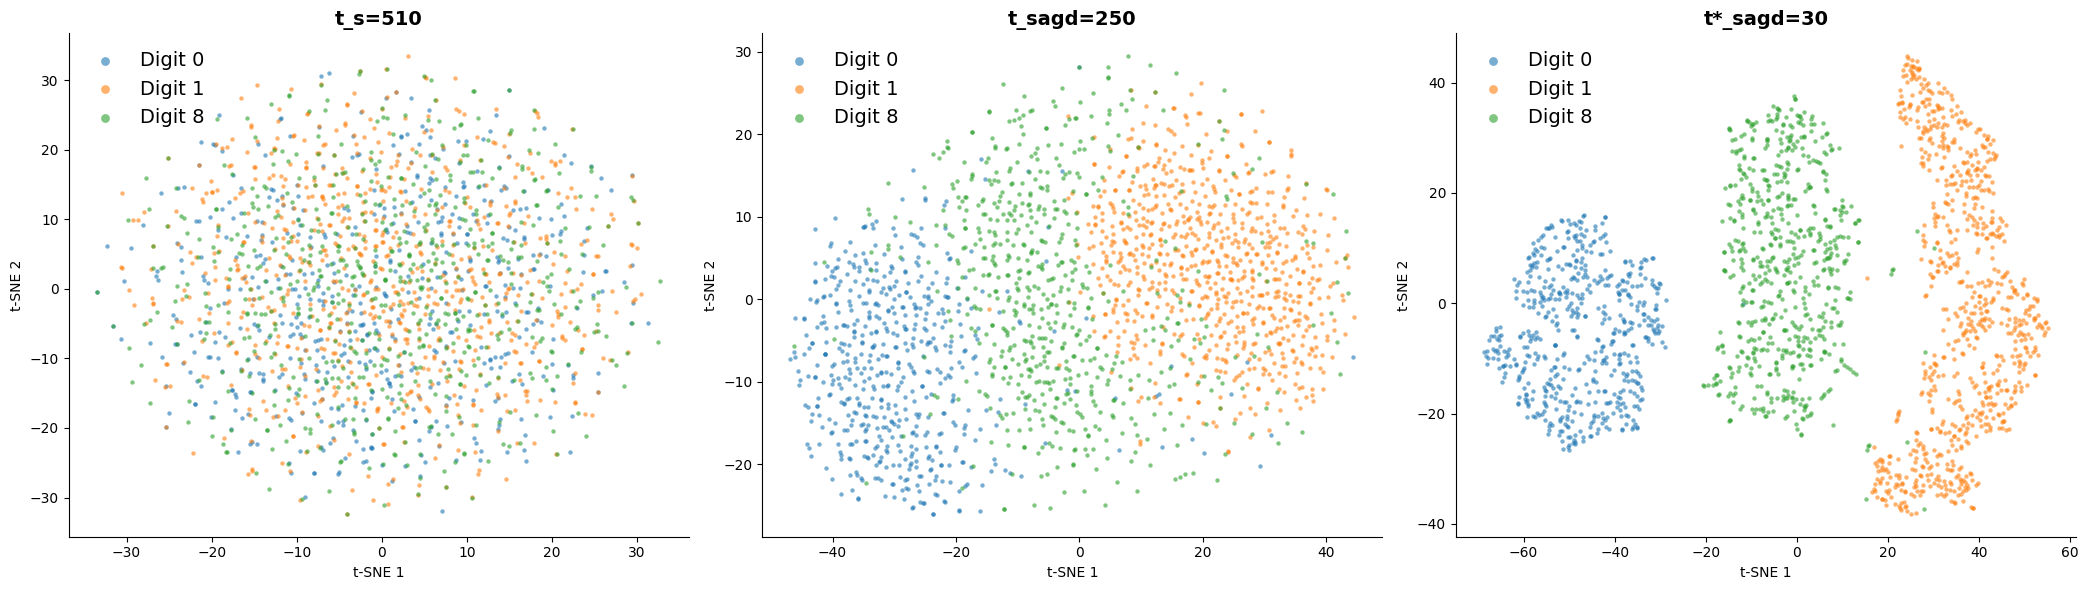

In [21]:
n = len(indcs)
fig, axes = plt.subplots(1, n, figsize=(7 * n, 6))
if n == 1:
    axes = [axes]

for count, (ax, idx) in enumerate(zip(axes, indcs)):
    X_final = history[snaps[idx]]  # (N, C, H, W)
    X_flat = X_final.reshape(2000, -1)  # (2000, 1024)
    X_pca = PCA(n_components=50).fit_transform(X_flat)
    plot_tsne(X_pca,
              node_labels,
              title=f"{t_titles[count]}={tss[count]}",
              ax=ax,
              save=False,
              class_names={0: 'Digit 0', 1: 'Digit 1', 2: 'Digit 8'})
plt.tight_layout()
plt.savefig("figs/tsne_3row.jpg", dpi=150, bbox_inches='tight')
plt.show()

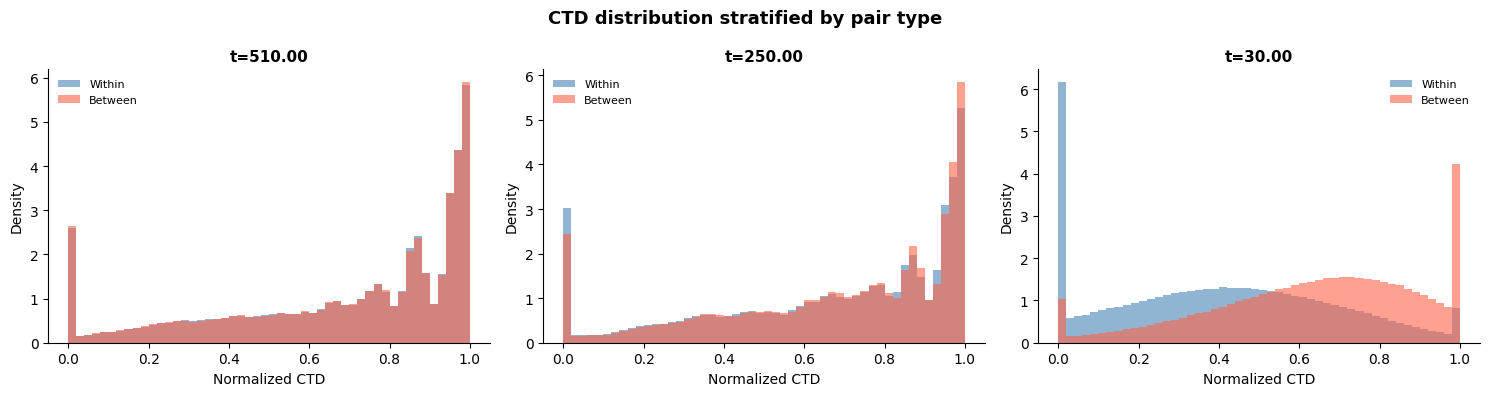

In [22]:
plot_ctd_stratified(ctds, sagd_dms[0], node_labels, snaps, t_values_to_plot=[snaps[idx] for idx in indcs])